# Batch Accumulation with Perspic

This notebook demonstrates how to use **gradient accumulation** with the `perspic` analyzer.
Gradient accumulation lets you simulate a large effective batch size while only fitting a small micro-batch in GPU memory.

We train a small Vision Transformer on CIFAR-10 and compare training **with** and **without** batch accumulation.

In [1]:
import os

import pytorch_lightning as pl
import torch
import torchvision
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10
from torchvision.models import VisionTransformer

from perspic.analyzer import analyzer
from examples.models import ClassificationModule

pl.seed_everything(7)

PATH_DATASETS = os.environ.get("PATH_DATASETS", ".")
MICRO_BATCH_SIZE = 64
EFFECTIVE_BATCH_SIZE = 256  # 4x accumulation
NUM_WORKERS = int(os.cpu_count() / 2)

Seed set to 7


## Data Setup

In [2]:
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomCrop(32, padding=4),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])

train_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=train_transform)
val_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=test_transform)
test_set = CIFAR10(PATH_DATASETS, train=False, download=True, transform=test_transform)

generator = torch.Generator().manual_seed(42)
train_set, _ = random_split(train_dataset_full, [45000, 5000], generator=generator)
_, val_set = random_split(val_dataset_full, [45000, 5000], generator=generator)

# Use micro-batch size for the DataLoader — accumulation handles the rest
train_dataloader = DataLoader(train_set, batch_size=MICRO_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_dataloader = DataLoader(val_set, batch_size=MICRO_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)
test_dataloader = DataLoader(test_set, batch_size=MICRO_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)

100%|██████████| 170M/170M [00:07<00:00, 23.0MB/s] 


## Model Definition

A small Vision Transformer suitable for CIFAR-10.

In [3]:
model_vit = VisionTransformer(
    image_size=32,
    patch_size=8,
    num_layers=2,
    num_heads=4,
    hidden_dim=128,
    mlp_dim=256,
    num_classes=10,
)

## Training with Batch Accumulation

The key parameters are `micro_batch_size` and `effective_batch_size`. The analyzer will:
- Zero gradients only at the start of each accumulation cycle
- Scale the loss by `1 / accumulation_steps` during backward
- Step the optimizer only after `accumulation_steps = effective_batch_size // micro_batch_size` micro-batches
- Accumulate analysis metrics across micro-batches and log once per effective step

In [4]:
vit_accum = analyzer(
    lightning_module=ClassificationModule,
    sample_wise_engine="opacus",
    micro_batch_size=MICRO_BATCH_SIZE,
    effective_batch_size=EFFECTIVE_BATCH_SIZE,
    model=model_vit,
    lr=0.005,
)

print(f"Accumulation steps: {vit_accum.accumulation_steps}")
print(f"Micro-batch size:   {MICRO_BATCH_SIZE}")
print(f"Effective batch:    {EFFECTIVE_BATCH_SIZE}")

Accumulation steps: 4
Micro-batch size:   64
Effective batch:    256


In [5]:
trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto",
    devices=1,
    logger=CSVLogger(save_dir="logs/", name="batch_accumulation"),
    callbacks=[LearningRateMonitor(logging_interval="step")],
    log_every_n_steps=1,
)

trainer.fit(vit_accum, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer.test(vit_accum, dataloaders=test_dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | VisionTransformer | 293 K  | train
----------------------------------------------------
293 K     Trainable params
0         Non-trainable params
293 K     Tota

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tikhome/jscheunemann/usr/miniconda3/envs/mast/lib/python3.13/site-packages/torch/autograd/graph.py:829: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::_scaled_dot_product_efficient_attention_backward. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:81.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.24599358439445496
        test_loss           2.0129430294036865
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 2.0129430294036865, 'test_acc': 0.24599358439445496}]

## Visualize Results

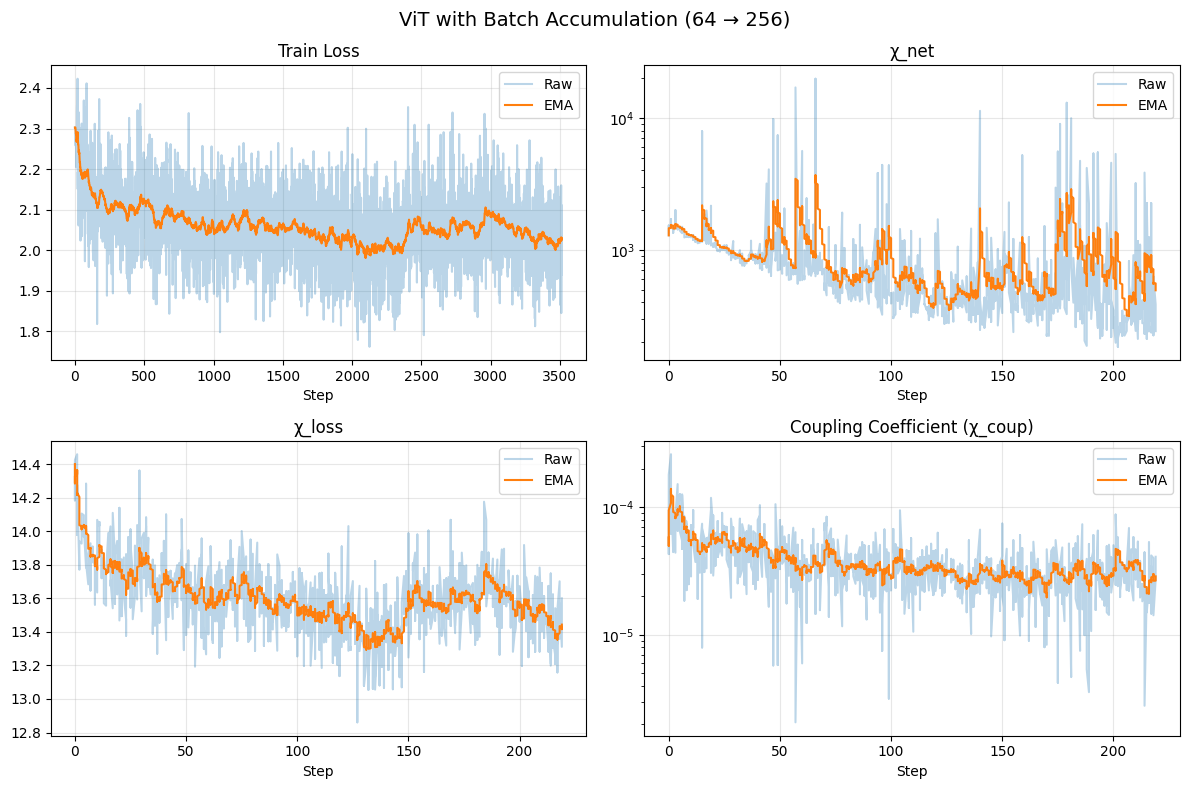

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"ViT with Batch Accumulation ({MICRO_BATCH_SIZE} → {EFFECTIVE_BATCH_SIZE})", fontsize=14)

# Loss
ax = axes[0, 0]
subset = metrics[["train_loss", "step"]].dropna()
ax.plot(subset["step"], subset["train_loss"], alpha=0.3, label="Raw")
ax.plot(subset["step"], subset["train_loss"].ewm(span=50).mean(), label="EMA")
ax.set_title("Train Loss")
ax.set_xlabel("Step")
ax.legend()
ax.grid(True, alpha=0.3)

# chi_net
ax = axes[0, 1]
step_col = "analysis_step" if "analysis_step" in metrics.columns else "step"
subset = metrics[["chi_net", step_col]].dropna()
if len(subset) > 0:
    ax.plot(subset[step_col], subset["chi_net"], alpha=0.3, label="Raw")
    ax.plot(subset[step_col], subset["chi_net"].ewm(span=50).mean(), label="EMA")
ax.set_title("χ_net")
ax.set_xlabel("Step")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

# chi_loss
ax = axes[1, 0]
subset = metrics[["chi_loss", step_col]].dropna()
if len(subset) > 0:
    ax.plot(subset[step_col], subset["chi_loss"], alpha=0.3, label="Raw")
    ax.plot(subset[step_col], subset["chi_loss"].ewm(span=50).mean(), label="EMA")
ax.set_title("χ_loss")
ax.set_xlabel("Step")
ax.legend()
ax.grid(True, alpha=0.3)

# Coupling
ax = axes[1, 1]
subset = metrics[["chi_coup", step_col]].dropna()
if len(subset) > 0:
    ax.plot(subset[step_col], subset["chi_coup"], alpha=0.3, label="Raw")
    ax.plot(subset[step_col], subset["chi_coup"].ewm(span=50).mean(), label="EMA")
ax.set_title("Coupling Coefficient (χ_coup)")
ax.set_xlabel("Step")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
metrics.keys()
metrics
metrics[["chi_net", "chi_loss", "chi_coup", "step"]]

,chi_net,chi_loss,chi_coup,step
0,NaN,NaN,NaN,0
1,NaN,NaN,NaN,0
2,NaN,NaN,NaN,1
3,NaN,NaN,NaN,1
4,NaN,NaN,NaN,2
...,...,...,...,...
7031,242.864716,13.59999,0.000041,3513
7032,NaN,NaN,NaN,3514
7033,242.864716,13.59999,0.000041,3514
7034,NaN,NaN,NaN,3514
